## A. Préparation de données

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import chisquare
from imblearn.over_sampling import RandomOverSampler
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
import nltk
nltk.download('punkt')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\pc\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [22]:
path = "cleaned_data.csv"
df = pd.read_csv(path)
df.head(10)


,id,author,cleaned_text
0,id26305,EAP,process however aforded aforded means ascerta...
1,id17569,HPL,never ocured fumbling might mere mistake
2,id11008,EAP,left hand gold snuff box capered hill cutting ...
3,id27763,MWS,lovely spring loked windsor terace sixteen fer...
4,id12958,HPL,finding nothing else even gold superintendent ...
5,id22965,MWS,youth pased solitude best years spent gentle f...
6,id09674,EAP,astronomer perhaps point took refuge suggestio...
7,id13515,EAP,surcingle hung ribands body
8,id19322,EAP,knew could say stereotomy without brought thin...
9,id00912,MWS,confess neither structure languages code gover...


## Check Class Distribution (Imbalance Analysis)

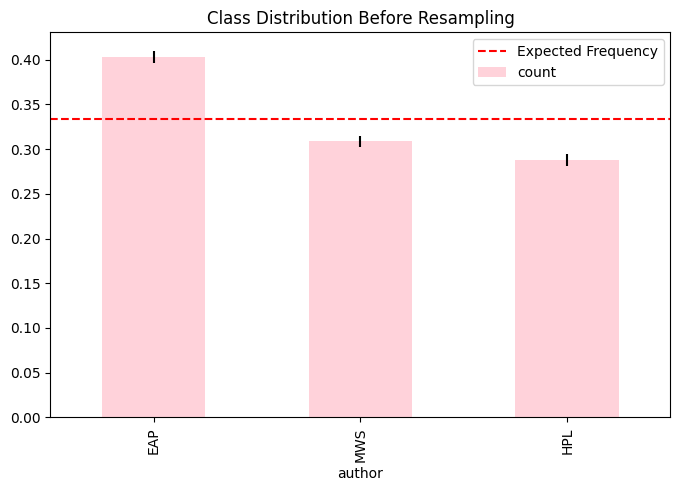

In [23]:
y = df["author"]

# Checking class imbalance
freqs = y.value_counts() / len(y)
std_errors = np.sqrt(freqs * (1 - freqs) / len(y))
expected_frequency = 1 / len(np.unique(y))

# Plot class distribution before resampling
plt.figure(figsize=(8, 5))
freqs.plot(kind='bar', yerr=std_errors * 1.96, alpha=0.7, color='pink')
plt.axhline(expected_frequency, color='red', linestyle='--', label='Expected Frequency')
plt.title("Class Distribution Before Resampling")
plt.legend()
plt.show()

## B. Encodage de la variable à prédire (facultatif)

l’encodage OneHot.

In [24]:
from sklearn.preprocessing import OneHotEncoder
import pandas as pd

encoder = OneHotEncoder(sparse_output=False)

encoded_labels = encoder.fit_transform(df[['author']])

encoded_df = pd.DataFrame(encoded_labels, columns=encoder.categories_[0]).astype(int)

df = pd.concat([df, encoded_df], axis=1)

df.head(10)


,id,author,cleaned_text,EAP,HPL,MWS
0,id26305,EAP,process however aforded aforded means ascerta...,1,0,0
1,id17569,HPL,never ocured fumbling might mere mistake,0,1,0
2,id11008,EAP,left hand gold snuff box capered hill cutting ...,1,0,0
3,id27763,MWS,lovely spring loked windsor terace sixteen fer...,0,0,1
4,id12958,HPL,finding nothing else even gold superintendent ...,0,1,0
5,id22965,MWS,youth pased solitude best years spent gentle f...,0,0,1
6,id09674,EAP,astronomer perhaps point took refuge suggestio...,1,0,0
7,id13515,EAP,surcingle hung ribands body,1,0,0
8,id19322,EAP,knew could say stereotomy without brought thin...,1,0,0
9,id00912,MWS,confess neither structure languages code gover...,0,0,1


## C. Construction des bases d’entraînement et de test

1. Diviser le dataset en deux parties : entrainement et test, en utilisant train_test_split, la taille du test 30%
et random_state=0.

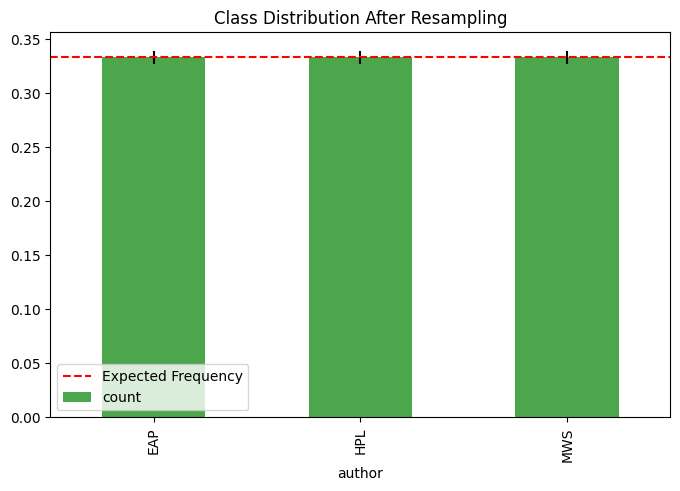

In [25]:
from imblearn.over_sampling import RandomOverSampler
import pandas as pd

y = df["author"]  
X = df[["cleaned_text"]]  

# Handling class imbalance using RandomOverSampler
ros = RandomOverSampler(random_state=42)
X_resampled, y_resampled = ros.fit_resample(X, y)

# Checking class distribution after resampling
freqs_resampled = y_resampled.value_counts() / len(y_resampled)
std_errors_resampled = np.sqrt(freqs_resampled * (1 - freqs_resampled) / len(y_resampled))

plt.figure(figsize=(8, 5))
freqs_resampled.plot(kind='bar', yerr=std_errors_resampled * 1.96, alpha=0.7, color='green')
plt.axhline(expected_frequency, color='red', linestyle='--', label='Expected Frequency')
plt.title("Class Distribution After Resampling")
plt.legend()
plt.show()



In [29]:
from sklearn.model_selection import train_test_split

X = X_resampled 
y = y_resampled 

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=0)

train_df = pd.concat([X_train, y_train], axis=1)
test_df = pd.concat([X_test, y_test], axis=1)

print("Training set size:", train_df.shape)
print("Test set size:", test_df.shape)


Training set size: (16590, 2)
Test set size: (7110, 2)


## D. Méthodes de vectorisation

1. Utiliser la méthode de fréquence lexicale et one-hot encoding pour vectoriser le dataset d’entrainement et
du test.

 Lexical Frequency (CountVectorizer)

In [30]:
df.head()

,id,author,cleaned_text,EAP,HPL,MWS
0,id26305,EAP,process however aforded aforded means ascerta...,1,0,0
1,id17569,HPL,never ocured fumbling might mere mistake,0,1,0
2,id11008,EAP,left hand gold snuff box capered hill cutting ...,1,0,0
3,id27763,MWS,lovely spring loked windsor terace sixteen fer...,0,0,1
4,id12958,HPL,finding nothing else even gold superintendent ...,0,1,0


In [43]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.preprocessing import OneHotEncoder

# Remplacer les valeurs NaN par une chaîne vide (ou autre valeur par défaut)
X_train_text = X_train["cleaned_text"].fillna("")  
X_test_text = X_test["cleaned_text"].fillna("")


# 1️Lexical Frequency Method (CountVectorizer)
cv = CountVectorizer()
X_train_cv = cv.fit_transform(X_train_text.astype(str))
X_test_cv = cv.transform(X_test_text.astype(str))


# Output Shapes
print("X_train_cv shape:", X_train_cv.shape) 
print("X_test_cv shape:", X_test_cv.shape)    



X_train_cv shape: (16590, 22611)
X_test_cv shape: (7110, 22611)


In [44]:
X_test_sample = df['cleaned_text'][:5]

X_test_sample_vectorized = cv.fit_transform(X_test_sample)

df_vectorized = pd.DataFrame(X_test_sample_vectorized.toarray(), columns=cv.get_feature_names_out())

print(df_vectorized)

   abandoned  aforded  air  ascertaining  atempts  aware  beneath  box  \
0          0        2    0             1        0      1        0    0   
1          0        0    0             0        0      0        0    0   
2          0        0    1             0        0      0        0    1   
3          0        0    0             0        0      0        1    0   
4          1        0    0             0        1      0        0    0   

   capered  cheering  ...  thinking  took  towns  uniform  wall  wealthier  \
0        0         0  ...         0     0      0        1     1          0   
1        0         0  ...         0     0      0        0     0          0   
2        1         0  ...         0     1      0        0     0          0   
3        0         1  ...         0     0      1        0     0          1   
4        0         0  ...         1     0      0        0     0          0   

   whence  windsor  without  years  
0       1        0        1      0  
1       0   

One-Hot Encoding 

In [45]:
from sklearn.feature_extraction.text import CountVectorizer

onehot_vectorizer = CountVectorizer(binary=True)

X_train_onehot = onehot_vectorizer.fit_transform(X_train_text)

X_test_onehot = onehot_vectorizer.transform(X_test_text)

print("One-Hot Encoding Training Shape:", X_train_onehot.shape)
print("One-Hot Encoding Test Shape:", X_test_onehot.shape)


One-Hot Encoding Training Shape: (16590, 22611)
One-Hot Encoding Test Shape: (7110, 22611)


In [46]:
X_test_sample = df['cleaned_text'][:5]

X_test_sample_vectorized = onehot_vectorizer.fit_transform(X_test_sample)

df_vectorized = pd.DataFrame(X_test_sample_vectorized.toarray(), columns=onehot_vectorizer.get_feature_names_out())

print(df_vectorized)

   abandoned  aforded  air  ascertaining  atempts  aware  beneath  box  \
0          0        1    0             1        0      1        0    0   
1          0        0    0             0        0      0        0    0   
2          0        0    1             0        0      0        0    1   
3          0        0    0             0        0      0        1    0   
4          1        0    0             0        1      0        0    0   

   capered  cheering  ...  thinking  took  towns  uniform  wall  wealthier  \
0        0         0  ...         0     0      0        1     1          0   
1        0         0  ...         0     0      0        0     0          0   
2        1         0  ...         0     1      0        0     0          0   
3        0         1  ...         0     0      1        0     0          1   
4        0         0  ...         1     0      0        0     0          0   

   whence  windsor  without  years  
0       1        0        1      0  
1       0   

2. Entrainer un modèle de vectorisation TF-IDF(Term Frequency - Inverse Document Frequency) sur la partie d’entrainement et vectorisez-le.

In [47]:

from sklearn.feature_extraction.text import TfidfVectorizer


# 2. Train a TF-IDF vectorization model on the training part and vectorize it.
tfidf_vectorizer = TfidfVectorizer()

X_train_tfidf = tfidf_vectorizer.fit_transform(X_train_text)
X_test_tfidf = tfidf_vectorizer.transform(X_test_text)  

# Afficher la forme du résultat
print("X_train_tfidf shape:", X_train_tfidf.shape)
print("X_test_tfidf shape:", X_test_tfidf.shape)


print("First 10 words in TF-IDF Vocabulary:", tfidf_vectorizer.get_feature_names_out()[:10])



X_train_tfidf shape: (16590, 22611)
X_test_tfidf shape: (7110, 22611)
First 10 words in TF-IDF Vocabulary: ['ab' 'abaft' 'abandon' 'abandoned' 'abandoning' 'abandonment' 'abaout'
 'abasement' 'abashment' 'abate']


In [48]:
X_test_sample = df['cleaned_text'][:5]

X_test_sample_vectorized = tfidf_vectorizer.fit_transform(X_test_sample)

df_vectorized = pd.DataFrame(X_test_sample_vectorized.toarray(), columns=tfidf_vectorizer.get_feature_names_out())

print(df_vectorized)

   abandoned  aforded       air  ascertaining   atempts     aware   beneath  \
0   0.000000  0.41125  0.000000      0.205625  0.000000  0.205625  0.000000   
1   0.000000  0.00000  0.000000      0.000000  0.000000  0.000000  0.000000   
2   0.000000  0.00000  0.220055      0.000000  0.000000  0.000000  0.000000   
3   0.000000  0.00000  0.000000      0.000000  0.000000  0.000000  0.208514   
4   0.252773  0.00000  0.000000      0.000000  0.252773  0.000000  0.000000   

        box   capered  cheering  ...  thinking      took     towns   uniform  \
0  0.000000  0.000000  0.000000  ...  0.000000  0.000000  0.000000  0.205625   
1  0.000000  0.000000  0.000000  ...  0.000000  0.000000  0.000000  0.000000   
2  0.220055  0.220055  0.000000  ...  0.000000  0.220055  0.000000  0.000000   
3  0.000000  0.000000  0.208514  ...  0.000000  0.000000  0.208514  0.000000   
4  0.000000  0.000000  0.000000  ...  0.252773  0.000000  0.000000  0.000000   

       wall  wealthier    whence   windsor  

## E. Entrainement

1. Créer trois modèles du type MLPClassifier. (Vous pouvez changer l’algorithme d’apprentissage : utiliser
les autres algorithmes de scikit-learn)

In [49]:
from sklearn.neural_network import MLPClassifier

# Define models with more iterations
model1 = MLPClassifier(hidden_layer_sizes=(32, 64), max_iter=200, activation='relu', random_state=42)
model2 = MLPClassifier(hidden_layer_sizes=(32, 64), max_iter=200, activation='logistic', random_state=42)
model3 = MLPClassifier(hidden_layer_sizes=(32, 64), max_iter=200, activation='tanh', random_state=42)

In [50]:
def train(vectorizer, model, epochs = 10):
    X = None
    y = None

    if vectorizer == 'cv':
        X = X_train_cv
        y = y_train
    elif vectorizer == 'tfidf':
        X = X_train_tfidf
        y = y_train
    
    elif vectorizer == 'ohe':
        X = X_train_onehot
        y = y_train
    else:
        raise ValueError("Invalid vectorizer")
    

    losses = []
    prev_accuracy = None 

    for epoch in range(epochs):
        model.partial_fit(X, y, classes=np.unique(y_train))

        y_train_pred = model.predict(X)

        accuracy = accuracy_score(y, y_train_pred)
        precision = precision_score(y, y_train_pred, average='weighted')
        recall = recall_score(y, y_train_pred, average='weighted')
        f1 = f1_score(y, y_train_pred, average='weighted')

        print(f"Epoch {epoch+1}/{epochs} - Accuracy: {accuracy:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}, F1-score: {f1:.4f}")
        
        if prev_accuracy is not None:
            loss = accuracy - prev_accuracy
            losses.append(loss)
        prev_accuracy = accuracy
    
    dump(model, 'models/'+f"{model.activation}_{vectorizer}.joblib")

    return losses

In [ ]:
vectorizers = ['cv', 'tfidf' , 'ohe']
models = [model1, model2, model3]
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from joblib import dump
losses = {}

In [54]:
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from joblib import dump



for model in models:
    for vectorizer in vectorizers:
        print(f"Training model with {model.activation} activation functions and {vectorizer} vectorizer")
        loss = train(vectorizer, model, epochs=50)
        losses[f"{model.activation}_{vectorizer}"] = loss
        

Training model with relu activation functions and cv vectorizer
Epoch 1/50 - Accuracy: 0.9999, Precision: 0.9999, Recall: 0.9999, F1-score: 0.9999
Epoch 2/50 - Accuracy: 0.9999, Precision: 0.9999, Recall: 0.9999, F1-score: 0.9999
Epoch 3/50 - Accuracy: 0.9999, Precision: 0.9999, Recall: 0.9999, F1-score: 0.9999
Epoch 4/50 - Accuracy: 0.9999, Precision: 0.9999, Recall: 0.9999, F1-score: 0.9999
Epoch 5/50 - Accuracy: 0.9999, Precision: 0.9999, Recall: 0.9999, F1-score: 0.9999
Epoch 6/50 - Accuracy: 0.9999, Precision: 0.9999, Recall: 0.9999, F1-score: 0.9999
Epoch 7/50 - Accuracy: 0.9999, Precision: 0.9999, Recall: 0.9999, F1-score: 0.9999
Epoch 8/50 - Accuracy: 0.9999, Precision: 0.9999, Recall: 0.9999, F1-score: 0.9999
Epoch 9/50 - Accuracy: 0.9999, Precision: 0.9999, Recall: 0.9999, F1-score: 0.9999
Epoch 10/50 - Accuracy: 0.9999, Precision: 0.9999, Recall: 0.9999, F1-score: 0.9999
Epoch 11/50 - Accuracy: 0.9999, Precision: 0.9999, Recall: 0.9999, F1-score: 0.9999
Epoch 12/50 - Accurac

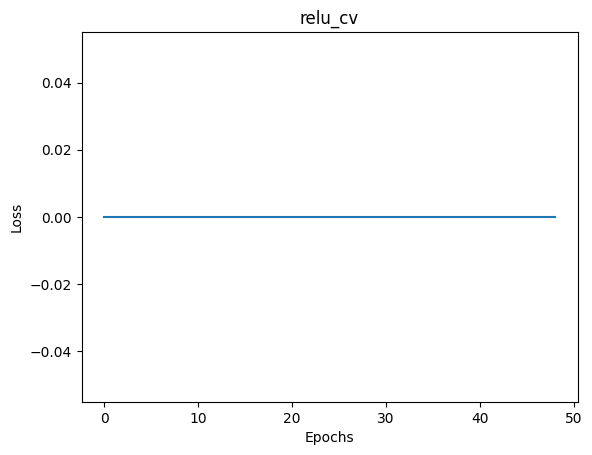

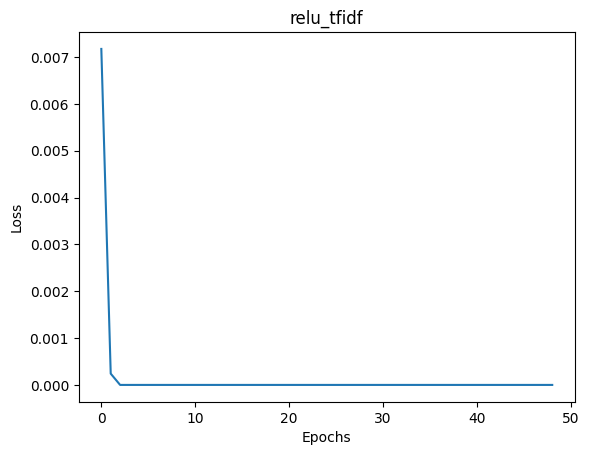

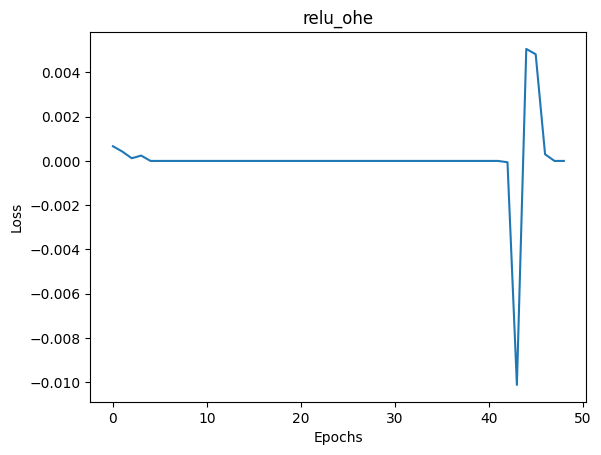

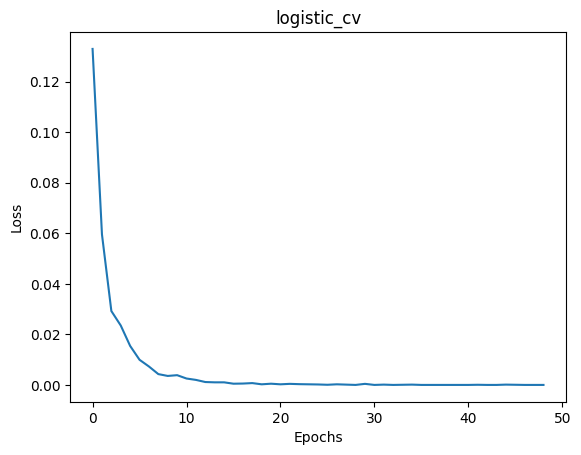

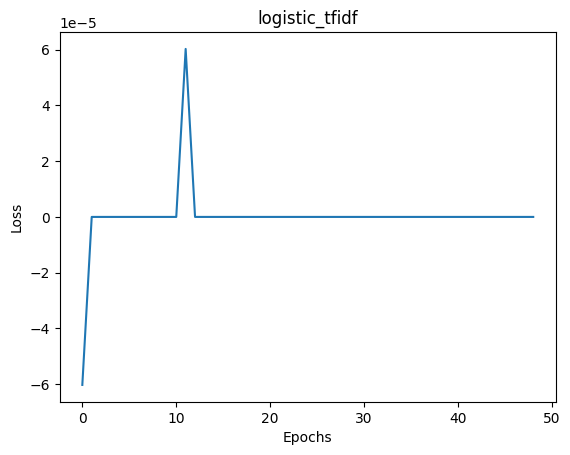

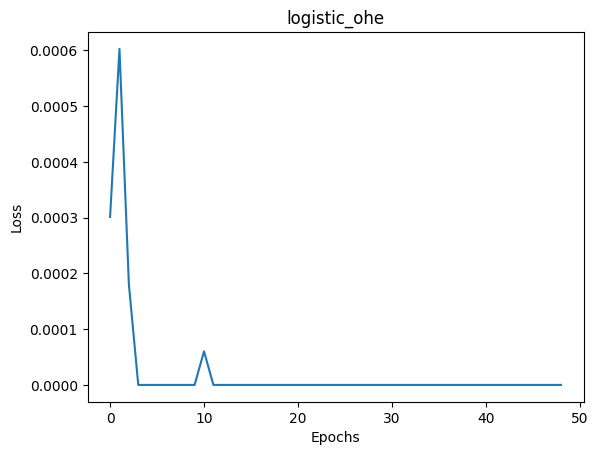

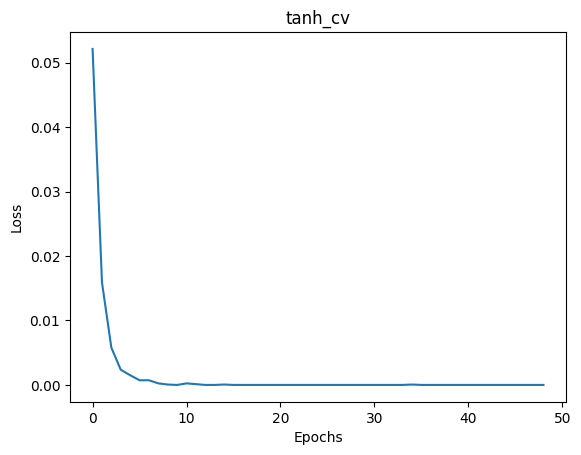

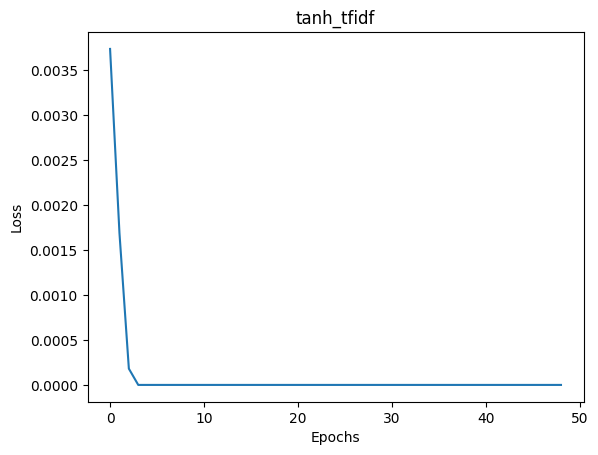

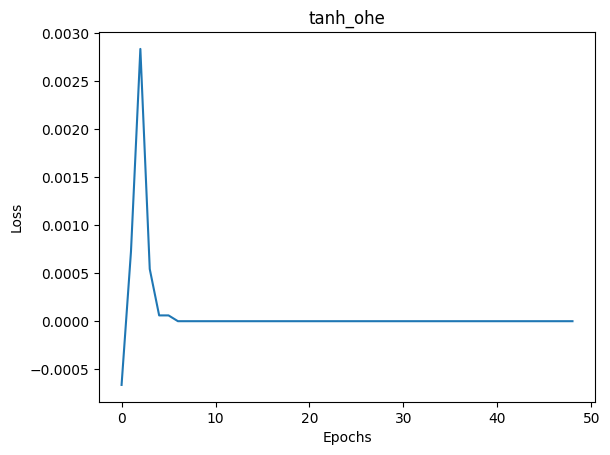

In [55]:
#plot the losses each in a different figure
for key, loss in losses.items():
    plt.figure()
    plt.plot(loss)
    plt.title(key)
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.show()

2. Entrainer ces trois modèles sur les trois représentations vectorielles.

3. Prédire les classes en appliquant les trois modèles sur les trois représentations d’entrainement.
4. Afficher le rapport de classification en utilisant les mesures de performance (accuracy, precision,
recall...).

## F. TEST

1. Prédire les classes en appliquant les trois modèles sur les trois représentations de test.
2. Afficher le rapport de classification en utilisant les mesures de performance (accuracy, precision,
recall...)

In [69]:
import time
from joblib import dump, load
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

# Load the models from the 'models' folder and display the classification report for each model
X = None
# Create a dataframe to store the accuracy, precision, recall, f1-score, and prediction time for each model
evaluation = pd.DataFrame(columns=['Model', 'Vectorizer', 'Accuracy', 'Precision', 'Recall', 'F1-score', 'Prediction Time'])

for model in models:
    for vectorizer in vectorizers:
        print(f"Model with {model.activation} activation function and {vectorizer} vectorizer")
        path = 'models/'+f'{model.activation}_{vectorizer}.joblib'
        clf = load(path)
        print(clf)

        if vectorizer == 'cv':
            X = X_test_cv
        elif vectorizer == 'tfidf':
            X = X_test_tfidf   
        elif vectorizer == 'ohe':
            X = X_test_onehot

        # Measure prediction time
        start_time = time.time()
        y_pred = clf.predict(X)
        prediction_time = time.time() - start_time
        print(f"Prediction Time ({vectorizer}): {prediction_time:.4f} seconds")

        # Convert predictions to encoded form if necessary
        y_pred = le.transform(y_pred)

        # Print classification report
        print(classification_report(y_test, y_pred, target_names=le.classes_))
        print('---------------------------------------------------')

        # Save accuracy, precision, recall, f1-score in a dataframe
        accuracy = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred, average='weighted')
        recall = recall_score(y_test, y_pred, average='weighted')
        f1 = f1_score(y_test, y_pred, average='weighted')

        new_row = pd.DataFrame([{
            'Model': model.activation, 
            'Vectorizer': vectorizer, 
            'Accuracy': accuracy, 
            'Precision': precision, 
            'Recall': recall, 
            'F1-score': f1,
            'Prediction Time': prediction_time
        }])

        evaluation = pd.concat([evaluation, new_row], ignore_index=True)


Model with relu activation function and cv vectorizer
MLPClassifier(hidden_layer_sizes=(32, 64), random_state=42)
Prediction Time (cv): 0.0265 seconds
              precision    recall  f1-score   support

         EAP       0.76      0.76      0.76      2370
         HPL       0.83      0.84      0.84      2370
         MWS       0.81      0.80      0.80      2370

    accuracy                           0.80      7110
   macro avg       0.80      0.80      0.80      7110
weighted avg       0.80      0.80      0.80      7110

---------------------------------------------------
Model with relu activation function and tfidf vectorizer
MLPClassifier(hidden_layer_sizes=(32, 64), random_state=42)
Prediction Time (tfidf): 0.0160 seconds
              precision    recall  f1-score   support

         EAP       0.78      0.79      0.78      2370
         HPL       0.84      0.86      0.85      2370
         MWS       0.84      0.81      0.82      2370

    accuracy                           0.

C:\Users\pc\AppData\Local\Temp\ipykernel_16084\1708692369.py:54: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  evaluation = pd.concat([evaluation, new_row], ignore_index=True)


Model with logistic activation function and cv vectorizer
MLPClassifier(activation='logistic', hidden_layer_sizes=(32, 64),
              random_state=42)
Prediction Time (cv): 0.0476 seconds
              precision    recall  f1-score   support

         EAP       0.79      0.79      0.79      2370
         HPL       0.85      0.87      0.86      2370
         MWS       0.84      0.82      0.83      2370

    accuracy                           0.83      7110
   macro avg       0.83      0.83      0.83      7110
weighted avg       0.83      0.83      0.83      7110

---------------------------------------------------
Model with logistic activation function and tfidf vectorizer
MLPClassifier(activation='logistic', hidden_layer_sizes=(32, 64),
              random_state=42)
Prediction Time (tfidf): 0.0400 seconds
              precision    recall  f1-score   support

         EAP       0.77      0.81      0.79      2370
         HPL       0.83      0.87      0.85      2370
         MWS  

## G. Vectorisations basées sur les embeddings de mots

In [70]:
!python -m pip install -U gensim

  Using cached gensim-4.3.3-cp312-cp312-win_amd64.whl.metadata (8.2 kB)
  Using cached scipy-1.13.1-cp312-cp312-win_amd64.whl.metadata (60 kB)
Using cached gensim-4.3.3-cp312-cp312-win_amd64.whl (24.0 MB)
Using cached scipy-1.13.1-cp312-cp312-win_amd64.whl (45.9 MB)
  Attempting uninstall: scipy
    Found existing installation: scipy 1.14.1
    Uninstalling scipy-1.14.1:
      Successfully uninstalled scipy-1.14.1


  You can safely remove it manually.
  You can safely remove it manually.

[notice] A new release of pip is available: 24.3.1 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [71]:

import nltk
from nltk.tokenize import word_tokenize
import pandas as pd


In [ ]:
words = df_resampled['cleaned_text'].dropna().apply(word_tokenize).tolist() 
words

[['process',
  'however',
  'aforded',
  'aforded',
  'means',
  'ascertaining',
  'dimensions',
  'dungeon',
  'might',
  'make',
  'circuit',
  'return',
  'point',
  'whence',
  'set',
  'without',
  'aware',
  'fact',
  'perfectly',
  'uniform',
  'semed',
  'wall'],
 ['never', 'ocured', 'fumbling', 'might', 'mere', 'mistake'],
 ['left',
  'hand',
  'gold',
  'snuff',
  'box',
  'capered',
  'hill',
  'cutting',
  'manner',
  'fantastic',
  'steps',
  'took',
  'snuff',
  'incessantly',
  'air',
  'greatest',
  'possible',
  'self',
  'satisfaction'],
 ['lovely',
  'spring',
  'loked',
  'windsor',
  'terace',
  'sixteen',
  'fertile',
  'counties',
  'spread',
  'beneath',
  'speckled',
  'happy',
  'cotages',
  'wealthier',
  'towns',
  'loked',
  'former',
  'years',
  'heart',
  'cheering',
  'fair'],
 ['finding',
  'nothing',
  'else',
  'even',
  'gold',
  'superintendent',
  'abandoned',
  'atempts',
  'perplexed',
  'look',
  'occasionally',
  'steals',
  'countenance',
  '

1. Utiliser les techniques de représentation vectorielle basées sur les prolongements de mots (Word
embedding) :

a. Word2Vec (CBOW et Skip gram)

## CBOW 

In [ ]:
import numpy as np
import pandas as pd
import nltk
from nltk.tokenize import word_tokenize


nltk.download('punkt')
def prepare_data(df):
    sentences = df_resampled['cleaned_text'].dropna().head(50).apply(word_tokenize).tolist()
    corpus = [word.lower() for sentence in sentences for word in sentence]  
    vocabulary = list(set(corpus))  
    word_to_index = {word: idx for idx, word in enumerate(vocabulary)}
    V = len(vocabulary) 
    return corpus, vocabulary, word_to_index, V

def one_hot_encoding(word, V, word_to_index):
    vector = np.zeros(V)
    vector[word_to_index[word]] = 1
    return vector.reshape(V, 1)

def generate_training_data(corpus, word_to_index, V, window_size=2):
    data = []
    for i in range(len(corpus)):
        target_word = corpus[i]
        context_words = [corpus[j] for j in range(max(0, i - window_size), min(len(corpus), i + window_size + 1)) if j != i]
        
        if context_words:
            context_one_hot = np.sum([one_hot_encoding(word, V, word_to_index) for word in context_words], axis=0)
            target_one_hot = one_hot_encoding(target_word, V, word_to_index)
            data.append((context_one_hot, target_one_hot))
    return data

class CBOWModel:
    def __init__(self, V, N):
        self.V = V 
        self.N = N  
        self.W = np.random.randn(V, N) * 0.1  
        self.W_prime = np.random.randn(N, V) * 0.1  

    def forward_propagation(self, context):
        h = np.dot(self.W.T, context)  
        u = np.dot(self.W_prime.T, h)  
        exp_u = np.exp(u)
        y = exp_u / np.sum(exp_u)  
        return h, u, y

    def calculate_log_loss(self, y, target): 
        target_index = np.argmax(target)  
        return -np.log(y[target_index, 0])

    def backpropagation(self, context, target, h, y, learning_rate=0.01):
        dW_prime = np.outer(h.flatten(), (y.flatten() - target.flatten()))  
        error_hidden = np.dot(self.W_prime, (y - target))
        dW = np.outer(context.flatten(), error_hidden.flatten())  

        self.W_prime -= learning_rate * dW_prime
        self.W -= learning_rate * dW

    def train(self, training_data, epochs=500, learning_rate=0.01):
        for epoch in range(epochs):
            total_loss = 0
            for context, target in training_data:
                h, u, y = self.forward_propagation(context)
                loss = self.calculate_log_loss(y, target)
                total_loss += loss
                self.backpropagation(context, target, h, y, learning_rate)
            
            if epoch % 100 == 0:
                print(f"Epoch {epoch}, Average Loss: {total_loss / len(training_data)}")

    def predict(self, context_words, word_to_index):
        V = self.V
        context_vectors = np.zeros((V, 1))  

        for word in context_words:
            if word in word_to_index:
                context_vectors += one_hot_encoding(word, V, word_to_index)
            else:
                print(f"Word '{word}' not in vocabulary!")
                return None  

        _, _, y = self.forward_propagation(context_vectors)
        predicted_index = np.argmax(y)
        predicted_word = [word for word, idx in word_to_index.items() if idx == predicted_index][0]

        return predicted_word

def cosine_similarity(vec1, vec2):
    return np.dot(vec1, vec2) / (np.linalg.norm(vec1) * np.linalg.norm(vec2))

if __name__ == "__main__":
    df_resampled = pd.read_csv("cleaned_data.csv") 
    corpus, vocabulary, word_to_index, V = prepare_data(df_resampled)
    training_data = generate_training_data(corpus, word_to_index, V, window_size=3)
    
    model = CBOWModel(V, N=5)  # Hidden layer size N=5
    model.train(training_data, epochs=1000, learning_rate=0.01)



[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\pc\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


Epoch 0, Average Loss: 6.5352410049196274
Epoch 100, Average Loss: 2.9194921460402967
Epoch 200, Average Loss: 1.485138883246744
Epoch 300, Average Loss: 0.722117017283237
Epoch 400, Average Loss: 0.33103584558978844
Epoch 500, Average Loss: 0.17495988079647218
Epoch 600, Average Loss: 0.10958406027842495
Epoch 700, Average Loss: 0.07710596931472755
Epoch 800, Average Loss: 0.05847045109591869
Epoch 900, Average Loss: 0.046614367727521006


In [17]:
    # Print word embeddings
    print("\nWord Embeddings (W matrix):")
    print(model.W)

    # Example: Fetch embedding for a word
    word = "abandoned"
    if word in word_to_index:
        word_index = word_to_index[word]
        embedding = model.W[word_index]
        print(f"\nEmbedding for '{word}': {embedding}")
    else:
        print(f"\nWord '{word}' not found in vocabulary.")

    # Compute cosine similarity between word pairs
    word_pairs = [("superintendent", "abandoned"), ("else", "even")]

    print("\nCosine Similarities:")
    for w1, w2 in word_pairs:
        w1, w2 = w1.lower(), w2.lower()  
        if w1 in word_to_index and w2 in word_to_index:
            sim = cosine_similarity(model.W[word_to_index[w1]], model.W[word_to_index[w2]])
            print(f"Similarity between '{w1}' and '{w2}': {sim:.4f}")
        else:
            print(f"One or both words ('{w1}', '{w2}') are missing in vocabulary.")



Word Embeddings (W matrix):
[[ 0.97889467 -1.19334672  0.92144634 -0.6949893  -2.73443819]
 [-0.58468605  1.30151618  1.89622762  1.81882437  2.02124772]
 [-1.27845677  1.89682551 -0.31942456 -0.99269767  2.53962481]
 ...
 [-2.44162557  0.94098367  2.93594774  0.66702357  0.7423765 ]
 [-0.38607365  2.31876868 -0.55043513  1.05588402 -2.7235582 ]
 [ 1.78635072  0.62740595 -0.85766586  2.90039985 -1.95258983]]

Embedding for 'abandoned': [ 2.83105494  1.05512388  1.85045036 -2.96782672  0.61529329]

Cosine Similarities:
Similarity between 'superintendent' and 'abandoned': 0.5168
Similarity between 'else' and 'even': 0.5583


In [18]:
test_context = ["superintendent","abandoned"] 
# corpus = "I like natural language processing. I enjoy deep learning. Machine learning interesting.".lower().split()

predicted_word = model.predict(test_context, word_to_index)

if predicted_word:
    print(f"\nPredicted Target Word for Context {test_context}: '{predicted_word}'")



Predicted Target Word for Context ['superintendent', 'abandoned']: 'atempts'


In [78]:
#1=> training
# CBOW Model =>  predicts a target word using its surrounding words
w2v_cbow = Word2Vec(sentences, vector_size=100, window=5, min_count=2, workers=4, sg=0)

# Skip-gram Model=> does the opposite—it predicts surrounding words based on a single word
w2v_skipgram = Word2Vec(sentences, vector_size=100, window=5, min_count=2, workers=4, sg=1)


In [79]:
w2v_cbow.save("word2vec_cbow.model")
w2v_skipgram.save("word2vec_skipgram.model")

# CBOW is like a teacher: Given a sentence with a missing word, it guesses the missing word.
# Skip-Gram is like a detective: Given one word, it finds related words nearby.

# CBOW → Good for common words and fast training
# Skip-Gram → Better for rare words but takes longer

In [80]:
#vector 
print(w2v_cbow.wv['ghost'])  

#similar words
print(w2v_cbow.wv.most_similar('beauty', topn=5))


[-0.09855615  0.23544756  0.09434627  0.00270665 -0.0064247  -0.33106175
  0.06727768  0.43775678 -0.12595741 -0.12282132 -0.08543165 -0.33512804
  0.00669328  0.05901152  0.03728492 -0.12595572  0.06937425 -0.18781884
  0.01393172 -0.44464692  0.08790472  0.07929362  0.15266785 -0.11800869
 -0.00412939  0.0059451  -0.07692049 -0.10576776 -0.18868461  0.05254234
  0.22869916  0.01027996  0.01910804 -0.09768409 -0.01222911  0.23098676
  0.12561053 -0.15380503 -0.10340101 -0.36379486  0.05077159 -0.16857278
 -0.08144421  0.01930244  0.15098257 -0.11629301 -0.17880127  0.08360953
  0.07092497  0.11695794  0.05738691 -0.20053025 -0.15042727 -0.0291925
 -0.19418325  0.12155976  0.11662497  0.0845461  -0.1713152   0.08256902
  0.04355717  0.07904071 -0.01856299  0.00183671 -0.21064213  0.16650912
  0.05919297  0.09190147 -0.21202283  0.19656123 -0.11909561  0.13051586
  0.23835774 -0.08074936  0.14479338  0.14358018  0.01942231 -0.01334427
 -0.1890772   0.06275567 -0.08164109 -0.05138043 -0.

In [81]:
import numpy as np

def get_sentence_vector(sentence, model):
    words = word_tokenize(sentence)
    vectors = [model.wv[word] for word in words if word in model.wv]
    return np.mean(vectors, axis=0) if vectors else np.zeros(100)  

X_train_vectors_cbow = np.array([get_sentence_vector(text, w2v_cbow) for text in X_train['cleaned_text']])
X_test_vectors_cbow = np.array([get_sentence_vector(text, w2v_cbow) for text in X_test['cleaned_text']])


X_train_vectors_skip = np.array([get_sentence_vector(text, w2v_skipgram) for text in X_train['cleaned_text']])
X_test_vectors_skip = np.array([get_sentence_vector(text, w2v_skipgram) for text in X_test['cleaned_text']])


B-GLOVE

In [ ]:
import numpy as np

glove_path = "glove.6B.100d.txt" 
glove_embeddings = {}

with open(glove_path, "r", encoding="utf-8") as f:
    for line in f:
        values = line.split()
        word = values[0]
        vector = np.array(values[1:], dtype=np.float32)
        glove_embeddings[word] = vector

print("✅ GloVe Loaded! Total Words:", len(glove_embeddings))


✅ GloVe Loaded! Total Words: 400000


In [83]:
from sklearn.metrics.pairwise import cosine_similarity

def find_similar_words(word, embeddings, top_n=5):
    if word not in embeddings:
        return f"'{word}' not found in GloVe."

    word_vector = embeddings[word].reshape(1, -1) 
    similarities = {}

    for other_word, other_vector in embeddings.items():
        if other_word != word:  
            sim = cosine_similarity(word_vector, other_vector.reshape(1, -1))[0][0]
            similarities[other_word] = sim

    similar_words = sorted(similarities.items(), key=lambda x: x[1], reverse=True)[:top_n]
    return similar_words

print(find_similar_words('haunted', glove_embeddings))


[('ghost', 0.6652432), ('ghosts', 0.64977175), ('spooky', 0.6448112), ('haunting', 0.63022244), ('forgotten', 0.6197043)]


In [84]:
def get_sentence_vector(sentence, embeddings, dim=100):
    words = word_tokenize(sentence)
    vectors = [embeddings[word] for word in words if word in embeddings]
    return np.mean(vectors, axis=0) if vectors else np.zeros(dim)

X_train_vectors_glove = np.array([get_sentence_vector(text, glove_embeddings) for text in X_train['cleaned_text']])
X_test_vectors_glove = np.array([get_sentence_vector(text, glove_embeddings) for text in X_test['cleaned_text']])


c. FastText.

In [85]:
from gensim.models import FastText
from nltk.tokenize import word_tokenize


fasttext_model = FastText(sentences, vector_size=100, window=5, min_count=2, workers=4)

fasttext_model.save("fasttext.model")

print("✅ FastText Training Done!")


✅ FastText Training Done!


In [86]:
print(fasttext_model.wv['ghost'])  


[-0.0533734   0.23196481 -0.28335953 -0.02634593  0.35555843  0.54202807
  0.04602328  0.17322206  0.24017382 -0.43439046  0.1463296   0.16355947
 -0.17059806  0.41786098 -0.06406124 -0.038234    0.14402707 -0.3595174
 -0.65008277 -0.33187717 -0.357672    0.07250207 -0.20699297 -0.2865527
  0.11640523 -0.3358264  -0.29720846 -0.11878838  0.4588637  -0.05519825
  0.07280064  0.17512298  0.18336664 -0.11175501  0.06259421  0.18979739
  0.09930171  0.27477863 -0.3577281   0.20840162  0.19866545 -0.20104074
  0.14046031 -0.44360548 -0.32892603 -0.2536577  -0.14038712  0.03667164
  0.13220453  0.02763652  0.22470236  0.05688146  0.2010617  -0.02372138
  0.09099973 -0.15911284 -0.31834763  0.20786181 -0.31273308 -0.23607542
  0.1328035  -0.18190998 -0.43315157  0.5214809  -0.02690175  0.21059743
  0.00203141 -0.01145121  0.28324506  0.5585201  -0.00093849 -0.12640408
  0.06558423 -0.21311387  0.23651858  0.00896543  0.27399963 -0.197557
  0.09150124  0.28871328 -0.06068796 -0.09426246 -0.412

In [87]:
print(fasttext_model.wv.most_similar('haunted', topn=5))


[('plotted', 0.9999892115592957), ('emited', 0.999988853931427), ('halted', 0.9999881982803345), ('abuted', 0.9999879598617554), ('melted', 0.999987006187439)]


In [88]:
import numpy as np

def get_fasttext_sentence_vector(sentence, model):
    words = word_tokenize(sentence)
    vectors = [model.wv[word] for word in words if word in model.wv]
    return np.mean(vectors, axis=0) if vectors else np.zeros(100)

X_train_vectors_fasttext = np.array([get_fasttext_sentence_vector(text, fasttext_model) for text in X_train['cleaned_text']])
X_test_vectors_fasttext = np.array([get_fasttext_sentence_vector(text, fasttext_model) for text in X_test['cleaned_text']])


## H. Entrainement / Test

In [89]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report

mlp_w2v_cbow = MLPClassifier(hidden_layer_sizes=(256, 128), 
                             activation='relu', 
                             solver='adam', 
                             alpha=0.0001, 
                             max_iter=500, 
                             random_state=0, 
                             learning_rate_init=0.001)

mlp_w2v_skip = MLPClassifier(hidden_layer_sizes=(256, 128), 
                             activation='relu', 
                             solver='adam', 
                             alpha=0.0001, 
                             max_iter=500, 
                             random_state=0, 
                             learning_rate_init=0.001)

mlp_glove = MLPClassifier(hidden_layer_sizes=(256, 128), 
                          activation='relu', 
                          solver='adam', 
                          alpha=0.0001, 
                          max_iter=500, 
                          random_state=0, 
                          learning_rate_init=0.001)

mlp_fasttext = MLPClassifier(hidden_layer_sizes=(256, 128), 
                             activation='relu', 
                             solver='adam', 
                             alpha=0.0001, 
                             max_iter=500, 
                             random_state=0, 
                             learning_rate_init=0.001)




In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_vectors_cbow = scaler.fit_transform(X_train_vectors_cbow)
X_test_vectors_cbow = scaler.transform(X_test_vectors_cbow)

X_train_vectors_skip = scaler.fit_transform(X_train_vectors_skip)
X_test_vectors_skip = scaler.transform(X_test_vectors_skip)

X_train_vectors_glove = scaler.fit_transform(X_train_vectors_glove)
X_test_vectors_glove = scaler.transform(X_test_vectors_glove)

X_train_vectors_fasttext = scaler.fit_transform(X_train_vectors_fasttext)
X_test_vectors_fasttext = scaler.transform(X_test_vectors_fasttext)


In [97]:
mlp_w2v_cbow.fit(X_train_vectors_cbow, y_train)


c:\Users\ikram\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:1105: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


MLPClassifier(hidden_layer_sizes=(256, 128), max_iter=500, random_state=0)

In [98]:
mlp_w2v_skip.fit(X_train_vectors_skip, y_train)


c:\Users\ikram\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:1105: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


MLPClassifier(hidden_layer_sizes=(256, 128), max_iter=500, random_state=0)

In [99]:
mlp_glove.fit(X_train_vectors_glove, y_train)


c:\Users\ikram\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:1105: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


MLPClassifier(hidden_layer_sizes=(256, 128), max_iter=500, random_state=0)

In [100]:
mlp_fasttext.fit(X_train_vectors_fasttext, y_train)

c:\Users\ikram\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:1105: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


MLPClassifier(hidden_layer_sizes=(256, 128), max_iter=500, random_state=0)

In [101]:
def predict_on_train(model, X_train, y_train, name):
    y_train_pred = model.predict(X_train)
    accuracy = model.score(X_train, y_train)
    
    print(f"\n🔹 MLP avec {name} - Accuracy sur l'entraînement: {accuracy:.4f}")
    print(classification_report(y_train, y_train_pred))

predict_on_train(mlp_w2v_cbow, X_train_vectors_cbow, y_train, "Word2Vec CBOW")
predict_on_train(mlp_w2v_skip, X_train_vectors_skip, y_train, "Word2Vec Skip-gram")
predict_on_train(mlp_glove, X_train_vectors_glove, y_train, "GloVe")
predict_on_train(mlp_fasttext, X_train_vectors_fasttext, y_train, "FastText")



🔹 MLP avec Word2Vec CBOW - Accuracy sur l'entraînement: 0.9041
              precision    recall  f1-score   support

         EAP       0.93      0.89      0.91      5527
         HPL       0.87      0.92      0.89      3944
         MWS       0.91      0.91      0.91      4230

    accuracy                           0.90     13701
   macro avg       0.90      0.91      0.90     13701
weighted avg       0.91      0.90      0.90     13701


🔹 MLP avec Word2Vec Skip-gram - Accuracy sur l'entraînement: 0.9923
              precision    recall  f1-score   support

         EAP       1.00      0.99      0.99      5527
         HPL       0.99      0.99      0.99      3944
         MWS       0.99      1.00      0.99      4230

    accuracy                           0.99     13701
   macro avg       0.99      0.99      0.99     13701
weighted avg       0.99      0.99      0.99     13701


🔹 MLP avec GloVe - Accuracy sur l'entraînement: 0.9986
              precision    recall  f1-score   sup

In [102]:
def predict_on_test(model, X_test, y_test, name):
    y_test_pred = model.predict(X_test)
    accuracy = model.score(X_test, y_test)
    
    print(f"\n🔹 MLP avec {name} - Accuracy sur le test: {accuracy:.4f}")
    print(classification_report(y_test, y_test_pred, zero_division=1)) 

predict_on_test(mlp_w2v_cbow, X_test_vectors_cbow, y_test, "Word2Vec CBOW")
predict_on_test(mlp_w2v_skip, X_test_vectors_skip, y_test, "Word2Vec Skip-gram")
predict_on_test(mlp_glove, X_test_vectors_glove, y_test, "GloVe")
predict_on_test(mlp_fasttext, X_test_vectors_fasttext, y_test, "FastText")




🔹 MLP avec Word2Vec CBOW - Accuracy sur le test: 0.5424
              precision    recall  f1-score   support

         EAP       0.59      0.53      0.56      2369
         HPL       0.50      0.54      0.52      1690
         MWS       0.52      0.55      0.54      1813

    accuracy                           0.54      5872
   macro avg       0.54      0.54      0.54      5872
weighted avg       0.55      0.54      0.54      5872


🔹 MLP avec Word2Vec Skip-gram - Accuracy sur le test: 0.6483
              precision    recall  f1-score   support

         EAP       0.67      0.65      0.66      2369
         HPL       0.64      0.59      0.61      1690
         MWS       0.64      0.69      0.66      1813

    accuracy                           0.65      5872
   macro avg       0.65      0.65      0.65      5872
weighted avg       0.65      0.65      0.65      5872


🔹 MLP avec GloVe - Accuracy sur le test: 0.6228
              precision    recall  f1-score   support

         EAP   

In [ ]:
import numpy as np
unique, counts = np.unique(y_train, return_counts=True)
print(dict(zip(unique, counts)))


{0.0: 27402, 1.0: 13701}
